In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/skindiseasedataset/Readme.md
/kaggle/input/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/dermatofibroma-103.jpeg
/kaggle/input/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/calcifying-epithelioma-7.jpeg
/kaggle/input/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/epidermal-cyst-147.jpeg
/kaggle/input/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/dermatofibroma-117.jpeg
/kaggle/input/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/porokeratosis-70.jpeg
/kaggle/input/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/skin-tags-polyps-44.jpeg
/kaggle/input/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/acquired-digital-fibrokeratoma-3.jpeg
/kaggle/input/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/connective-tissue-nevus-1.jpeg
/kaggle/input/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors/kyrle-disease-7.jpeg
/kaggle/input/skindiseasedataset/S

# Load the Dataset

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torchvision 
from PIL import Image
from torch.utils.data import DataLoader, random_split
import math

In [3]:
image_transforms=transforms.Compose([
     transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),       # Randomly flip images horizontally
    transforms.RandomRotation(10),
     transforms.ToTensor(),         # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize to range [-1, 1]

    
])

In [4]:
dataset_path= "/kaggle/input/skindiseasedataset/SkinDisease"
dataset = datasets.ImageFolder(dataset_path,transform = image_transforms)
len(dataset)

15444

In [5]:
train_dataset= '/kaggle/input/skindiseasedataset/SkinDisease/SkinDisease/train'
test_datset = '/kaggle/input/skindiseasedataset/SkinDisease/SkinDisease/test'

In [6]:
train_dataset = datasets.ImageFolder(train_dataset,transform = image_transforms)
test_dataset = datasets.ImageFolder(test_datset,transform = image_transforms)

In [7]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [8]:
train_dataset.classes

['Acne',
 'Actinic_Keratosis',
 'Benign_tumors',
 'Bullous',
 'Candidiasis',
 'DrugEruption',
 'Eczema',
 'Infestations_Bites',
 'Lichen',
 'Lupus',
 'Moles',
 'Psoriasis',
 'Rosacea',
 'Seborrh_Keratoses',
 'SkinCancer',
 'Sun_Sunlight_Damage',
 'Tinea',
 'Unknown_Normal',
 'Vascular_Tumors',
 'Vasculitis',
 'Vitiligo',
 'Warts']

In [9]:
num_classes = len(train_dataset.classes)
num_classes

22

In [10]:
for i, (images, labels) in enumerate(train_loader):
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 128, 128])
torch.Size([32])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7415688].


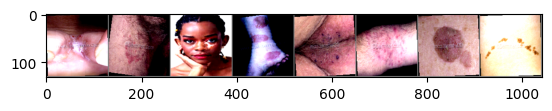

In [11]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# show images
imshow(torchvision.utils.make_grid(images[:8]))

# Transfer Learning with RestNet

In [12]:
def train_model(model, criterion, optimizer, epochs=5):
    start = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_loader):
            
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
            if (batch_num+1) % 10 == 0:
                print(f"Batch: {batch_num+1}, Epoch: {epoch+1}, Loss: {loss.item():0.2f}")
            
            running_loss += loss.item() * images.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {epoch_loss:.4f}")

        # Validation
        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []
        
        with torch.no_grad():
            for images, labels in test_loader:
               
                outputs = model(images)
                _, predicted = torch.max(outputs.data,1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())
                
            print(f"*** Validation Accuracy: {100 * correct / total:.2f}% ***")
            
    end = time.time()
    print(f"Execution time: {end - start} seconds")     
    
    return all_labels, all_predictions

In [13]:
# Load the pre-trained ResNet model
class CNNResNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        # Freeze all layers except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
            
        # Unfreeze layer4 and fc layers
        for param in self.model.layer4.parameters():
            param.requires_grad = True            
            
        # Replace the final fully connected layer
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features, num_classes)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [14]:
import torchvision.models as models
import time
model = CNNResNet(num_classes=num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

labels, predictions = train_model(model, criterion, optimizer, epochs=10)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]


Batch: 10, Epoch: 1, Loss: 2.73
Batch: 20, Epoch: 1, Loss: 2.39
Batch: 30, Epoch: 1, Loss: 2.43
Batch: 40, Epoch: 1, Loss: 2.59
Batch: 50, Epoch: 1, Loss: 2.35
Batch: 60, Epoch: 1, Loss: 1.87
Batch: 70, Epoch: 1, Loss: 2.26
Batch: 80, Epoch: 1, Loss: 2.26
Batch: 90, Epoch: 1, Loss: 1.97
Batch: 100, Epoch: 1, Loss: 2.05
Batch: 110, Epoch: 1, Loss: 1.90
Batch: 120, Epoch: 1, Loss: 2.06
Batch: 130, Epoch: 1, Loss: 2.07
Batch: 140, Epoch: 1, Loss: 2.59
Batch: 150, Epoch: 1, Loss: 2.41
Batch: 160, Epoch: 1, Loss: 1.81
Batch: 170, Epoch: 1, Loss: 1.83
Batch: 180, Epoch: 1, Loss: 1.71
Batch: 190, Epoch: 1, Loss: 1.55
Batch: 200, Epoch: 1, Loss: 2.13
Batch: 210, Epoch: 1, Loss: 1.64
Batch: 220, Epoch: 1, Loss: 1.63
Batch: 230, Epoch: 1, Loss: 1.50
Batch: 240, Epoch: 1, Loss: 1.84
Batch: 250, Epoch: 1, Loss: 2.08
Batch: 260, Epoch: 1, Loss: 1.99
Batch: 270, Epoch: 1, Loss: 1.22
Batch: 280, Epoch: 1, Loss: 1.41
Batch: 290, Epoch: 1, Loss: 1.26
Batch: 300, Epoch: 1, Loss: 2.04
Batch: 310, Epoch: 

In [15]:
from sklearn.metrics import classification_report

report = classification_report(labels, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.85      0.85      0.85        65
           1       0.65      0.64      0.64        83
           2       0.56      0.69      0.62       121
           3       0.56      0.53      0.54        55
           4       0.67      0.67      0.67        27
           5       0.60      0.57      0.59        61
           6       0.59      0.76      0.66       112
           7       0.57      0.53      0.55        60
           8       0.68      0.56      0.61        61
           9       0.62      0.44      0.52        34
          10       0.59      0.68      0.63        40
          11       0.74      0.65      0.69        88
          12       0.69      0.71      0.70        28
          13       0.67      0.69      0.68        51
          14       0.62      0.58      0.60        77
          15       0.46      0.32      0.38        34
          16       0.76      0.69      0.72       102
          17       0.94    

In [16]:
class_names= train_dataset.classes
class_names 

['Acne',
 'Actinic_Keratosis',
 'Benign_tumors',
 'Bullous',
 'Candidiasis',
 'DrugEruption',
 'Eczema',
 'Infestations_Bites',
 'Lichen',
 'Lupus',
 'Moles',
 'Psoriasis',
 'Rosacea',
 'Seborrh_Keratoses',
 'SkinCancer',
 'Sun_Sunlight_Damage',
 'Tinea',
 'Unknown_Normal',
 'Vascular_Tumors',
 'Vasculitis',
 'Vitiligo',
 'Warts']

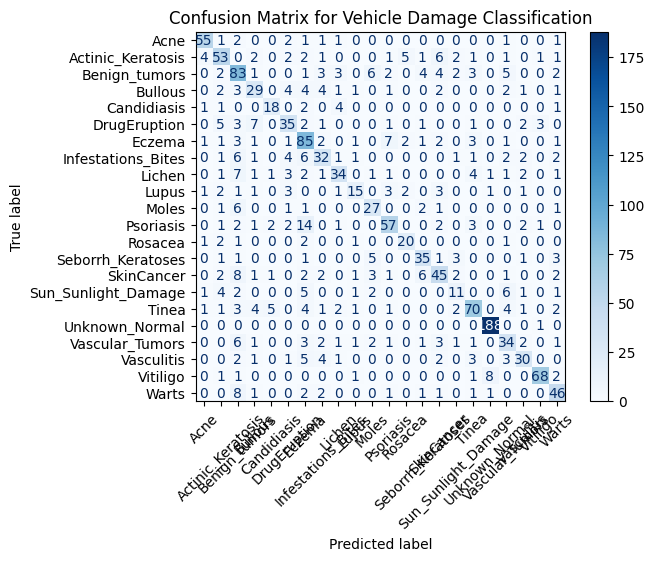

In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

conf_matrix = confusion_matrix(labels, predictions, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

# Save the model

In [18]:
torch.save(model.state_dict(), 'skin_model.pth')

# Testing the model

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6544228].


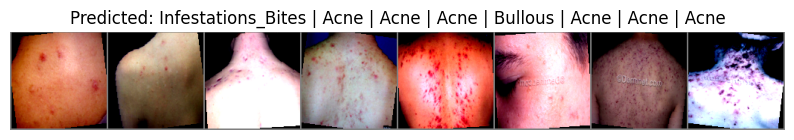

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision

# Helper function to unnormalize and show an image
def imshow(img, title=None):
    img = img / 2 + 0.5  # unnormalize (if normalized to mean=0.5, std=0.5)
    npimg = img.numpy()
    plt.figure(figsize=(10, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

# Get some test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Move model to eval mode and disable gradient tracking
model.eval()
with torch.no_grad():
    images = images
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Move tensors to CPU for visualization
images = images.cpu()
predicted = predicted.cpu()

# Show images with predicted labels (first 8)
imshow(torchvision.utils.make_grid(images[:8]),
       title='Predicted: ' + ' | '.join(class_names[pred] for pred in predicted[:8]))